In [17]:
print("c bon")

c bon


In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

In [19]:
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_path = os.path.join(self.image_dir, self.images[index])
        mask_path = os.path.join(self.mask_dir, self.masks[index])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        mask = (mask > 0).float()  # assure binaire 0/1

        return image, mask
    
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [20]:
train_image_dir = "data/train/images"
train_mask_dir = "data/train/masks"

test_image_dir = "data/train/images"
test_mask_dir = "data/train/masks"

full_dataset = SegmentationDataset(train_image_dir, train_mask_dir, transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

test_dataset = SegmentationDataset(test_image_dir, test_mask_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [21]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.model = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.model(x)


class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.c1 = DoubleConv(3, 16)
        self.p1 = Down(16, 32)
        self.p2 = Down(32, 64)
        self.p3 = Down(64, 128)
        self.p4 = Down(128, 256)

        self.u1 = Up(256, 128)
        self.u2 = Up(128, 64)
        self.u3 = Up(64, 32)
        self.u4 = Up(32, 16)

        self.out = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        c1 = self.c1(x)
        c2 = self.p1(c1)
        c3 = self.p2(c2)
        c4 = self.p3(c3)
        c5 = self.p4(c4)

        u1 = self.u1(c5, c4)
        u2 = self.u2(u1, c3)
        u3 = self.u3(u2, c2)
        u4 = self.u4(u3, c1)

        return self.out(u4)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

num_epochs = 1
train_losses = []
val_losses = []

best_val_loss = float('inf')
early_stop_counter = 0

In [23]:
for epoch in range(num_epochs):

    model.train()
    train_loss = 0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            val_loss += loss.item() * images.size(0)

    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    if early_stop_counter >= 10:
        print("Early stopping triggered")
        break

Epoch 1 | Train: 0.5833 | Val: 0.5562


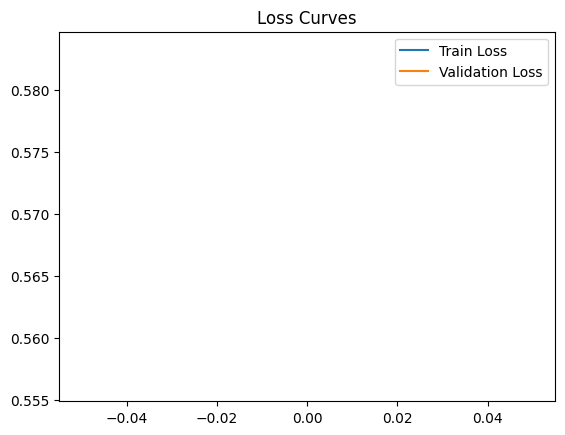

In [24]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curves")
plt.show()

In [25]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

def compute_metrics(pred, mask):
    pred = pred.view(-1)
    mask = mask.view(-1)

    intersection = (pred * mask).sum()
    union = pred.sum() + mask.sum() - intersection

    iou = intersection / (union + 1e-8)
    dice = (2 * intersection) / (pred.sum() + mask.sum() + 1e-8)

    return iou.item(), dice.item()

total_iou = 0
total_dice = 0

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)

        outputs = model(images)
        preds = torch.sigmoid(outputs)
        preds = (preds > 0.5).float()

        for i in range(images.size(0)):
            iou, dice = compute_metrics(preds[i], masks[i])
            total_iou += iou
            total_dice += dice

avg_iou = total_iou / len(test_dataset)
avg_dice = total_dice / len(test_dataset)

print(f"Test IoU: {avg_iou:.4f}")
print(f"Test Dice: {avg_dice:.4f}")

image, mask = test_dataset[0]

model.eval()
with torch.no_grad():
    input_tensor = image.unsqueeze(0).to(device)
    output = model(input_tensor)
    pred = torch.sigmoid(output)
    pred = (pred > 0.5).float()

pred = pred.squeeze().cpu().numpy()
mask = mask.squeeze().numpy()
image = image.permute(1,2,0).numpy()

Test IoU: 0.0000
Test Dice: 0.0000


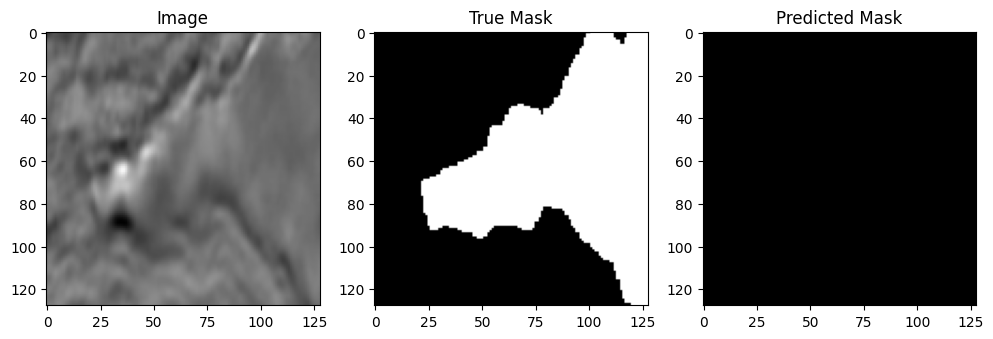

In [26]:
image, mask = test_dataset[150]

model.eval()
with torch.no_grad():
    input_tensor = image.unsqueeze(0).to(device)
    output = model(input_tensor)
    pred = torch.sigmoid(output)
    pred = (pred > 0.5).float()

pred = pred.squeeze().cpu().numpy()
mask = mask.squeeze().numpy()
image = image.permute(1,2,0).numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(image)

plt.subplot(1,3,2)
plt.title("True Mask")
plt.imshow(mask, cmap="gray")

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(pred, cmap="gray")

plt.show()